In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torchvision.models as models
import os
 
from olimp.dataset.olimp import olimp
from olimp.dataset import read_img_path

from olimp.dataset.olimp import olimp
from olimp.dataset import read_img_path

/home/user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#  2: Конфигурация

PATCH_SIZE        = 256
SIGMA             = 10 / 255.0
TRAIN_RATIO       = 0.85
 
PATCHES_PER_EPOCH = 50_000
VAL_PATCHES       = 5_000
 
BATCH_SIZE        = 8
NUM_WORKERS       = 4
EPOCHS            = 300
PATIENCE          = 30
LR                = 5e-4
 
CACHE_IMAGES      = True
 
CHECKPOINT_PATH   = "checkpoint(8).pt"
BEST_MODEL_PATH   = "best_model(8).pt"
ALL_MODELS_DIR    = "all_models(8)"
CHECKPOINT_EVERY  = 5
 
os.makedirs(ALL_MODELS_DIR, exist_ok=True)

In [4]:
# ЯЧЕЙКА 3: Загрузка датасета — 1000 изображений

CATEGORIES = [
    'abstracts and textures', 'abstracts and textures/abstract art',
    'abstracts and textures/backgrounds and patterns',
    'abstracts and textures/colorful abstracts',
    'abstracts and textures/geometric shapes',
    'abstracts and textures/neon abstracts', 'abstracts and textures/textures',
    'animals', 'animals/birds', 'animals/farm animals',
    'animals/insects and spiders', 'animals/marine life', 'animals/pets',
    'animals/wild animals', 'art and culture',
    'art and culture/cartoon and comics',
    'art and culture/crafts and handicrafts',
    'art and culture/dance and theater performances',
    'art and culture/music concerts and instruments',
    'art and culture/painting and frescoes',
    'art and culture/sculpture and bas-reliefs', 'food and drinks',
    'food and drinks/desserts and bakery', 'food and drinks/dishes',
    'food and drinks/drinks',
    'food and drinks/food products on store shelves',
    'food and drinks/fruits and vegetables', 'food and drinks/street food',
    'interiors', 'interiors/gyms and pools', 'interiors/living spaces',
    'interiors/museums and galleries', 'interiors/offices',
    'interiors/restaurants and cafes',
    'interiors/shopping centers and stores', 'nature', 'nature/beaches',
    'nature/deserts', 'nature/fields and meadows', 'nature/forest',
    'nature/mountains', 'nature/water bodies', 'objects and items',
    'objects and items/books and stationery',
    'objects and items/clothing and accessories',
    'objects and items/electronics and gadgets',
    'objects and items/furniture and decor',
    'objects and items/tools and equipment',
    'objects and items/toys and games', 'portraits and people',
    'portraits and people/athletes and dancers',
    'portraits and people/crowds and demonstrations',
    'portraits and people/group photos',
    'portraits and people/individual portraits',
    'portraits and people/models on runway',
    'portraits and people/workers in their workplaces',
    'sports and active leisure',
    'sports and active leisure/cycling and rollerblading',
    'sports and active leisure/extreme sports',
    'sports and active leisure/individual sports',
    'sports and active leisure/martial arts',
    'sports and active leisure/team sports',
    'sports and active leisure/tourism and hikes', 'text and pictogram',
    'text and pictogram/billboard text', 'text and pictogram/blueprints',
    'text and pictogram/caricatures and pencil drawing',
    'text and pictogram/text documents', 'text and pictogram/traffic signs',
    'urban scenes', 'urban scenes/architecture',
    'urban scenes/city at night', 'urban scenes/graffiti and street art',
    'urban scenes/parks and squares', 'urban scenes/streets and avenues',
    'urban scenes/transport',
]
 
all_paths = []
for cat in CATEGORIES:
    try:
        ds    = olimp(categories={cat})
        paths = ds[cat]
        all_paths.extend(paths)
    except Exception as e:
        print(f"  {cat}: пропущено ({e})")
 
rng = np.random.default_rng(42)
rng.shuffle(all_paths)
all_paths = all_paths[:1000]
print(f"\nИтого загружено: {len(all_paths)} изображений")
 
n_train     = int(TRAIN_RATIO * len(all_paths))
train_paths = all_paths[:n_train]
val_paths   = all_paths[n_train:]
print(f"Train: {len(train_paths)} изображений | Val: {len(val_paths)} изображений")

/home/user/.local/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')


Итого загружено: 1000 изображений
Train: 850 изображений | Val: 150 изображений


In [5]:
# ЯЧЕЙКА 4: Генерация конфигураций масок K
# Убрано: config_to_cond — вектор условия для FiLM больше не нужен.
# make_mask оставлен: K нужен при генерации обучающих P, но сети не передаётся.

_cfg_rng = np.random.default_rng(0)
 
stripe_h_configs = [
    {"type": "h", "width": float(w)}
    for w in _cfg_rng.uniform(4, 128, 1000)
]
 
sin_configs = [
    {
        "type": "s",
        "freq":  float(f),
        "angle": float(a),
        "phase": float(p),
    }
    for f, a, p in zip(
        _cfg_rng.uniform(1 / 120, 1 / 8, 1000),
        _cfg_rng.uniform(0, 180, 1000),
        _cfg_rng.uniform(0, 2 * np.pi, 1000),
    )
]
 
ALL_CONFIGS = stripe_h_configs + sin_configs
print(f"Всего конфигураций K: {len(ALL_CONFIGS)}  "
      f"(горизонтальных: {len(stripe_h_configs)}, "
      f"синусоидальных: {len(sin_configs)})")
 
 
def make_mask(h: int, w: int, config: dict) -> np.ndarray:
    """
    Генерирует маску K ∈ [0,1].
    Используется только при создании измерения P — сети не передаётся.
    """
    if config["type"] == "h":
        sw = max(1, int(config["width"]))
        y  = np.arange(h)
        K  = ((y // sw) % 2).astype(np.float32)
        return K[:, None] * np.ones((1, w), dtype=np.float32)
 
    freq  = config["freq"]
    angle = np.radians(config["angle"])
    phase = config["phase"]
    a = 2 * np.pi * freq * np.cos(angle)
    b = 2 * np.pi * freq * np.sin(angle)
    xs = np.arange(w, dtype=np.float32)[None, :]
    ys = np.arange(h, dtype=np.float32)[:, None]
    return ((np.sin(a * xs + b * ys + phase) + 1) / 2).astype(np.float32)

Всего конфигураций K: 2000  (горизонтальных: 1000, синусоидальных: 1000)


In [6]:
# ЯЧЕЙКА 5: Вспомогательные функции

def load_rg(img_path):
    img = read_img_path(img_path)
    img = np.array(img, dtype=np.float32) / 255.0
    img = np.transpose(img, (1, 2, 0))
    img = cv2.resize(img, (512, 512))
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    elif img.shape[2] == 1:
        img = np.concatenate([img, img, img], axis=-1)
    return img[:, :, :2].astype(np.float32)
 
 
def make_measurement(rg: np.ndarray, K: np.ndarray) -> np.ndarray:
    """P = K * R^0.7 + (1-K) * G^2 + N(0, σ)"""
    R = rg[:, :, 0]
    G = rg[:, :, 1]
    P = K * R ** 0.7 + (1 - K) * G ** 2
    noise = np.random.normal(0, SIGMA, P.shape).astype(np.float32)
    return np.clip(P + noise, 0, 1)

In [ ]:
# ЯЧЕЙКА 6: Предзагрузка изображений в RAM

def preload_images(paths, desc="Загрузка"):
    imgs = []
    for p in tqdm(paths, desc=desc):
        imgs.append(load_rg(p))
    t = torch.from_numpy(np.stack(imgs))
    t.share_memory_()
    return t
 
 
if CACHE_IMAGES:
    print("Предзагрузка train изображений...")
    train_images_tensor = preload_images(train_paths, desc="  train")
    print("Предзагрузка val изображений...")
    val_images_tensor   = preload_images(val_paths,   desc="  val  ")
    print(f"RAM: {(train_images_tensor.nbytes + val_images_tensor.nbytes) / 1e9:.2f} GB")
else:
    train_images_tensor = None
    val_images_tensor   = None

Предзагрузка train изображений...


  train: 100%|████████████████████████████████| 850/850 [03:26<00:00,  4.11it/s]


Предзагрузка val изображений...


  val  :  51%|████████████████▉                | 77/150 [00:14<00:20,  3.56it/s]

In [ ]:
# ЯЧЕЙКА 7: Dataset
#
# Главное изменение:
#   - inp теперь shape (1, H, W) — только P, без K
#   - __getitem__ возвращает (inp, target) без cond
#
# K по-прежнему генерируется внутри для вычисления P,
# но в тензор входа НЕ включается.

class DemuxDataset(Dataset):
    def __init__(
        self,
        images,
        configs,
        n_samples,
        patch_size=PATCH_SIZE,
        augment=True,
        seed=None,
    ):
        self.images     = images
        self.configs    = configs
        self.n_samples  = n_samples
        self.patch_size = patch_size
        self.augment    = augment
 
        n_img = images.shape[0] if isinstance(images, torch.Tensor) else len(images)
        H = images.shape[1] if isinstance(images, torch.Tensor) else 512
        W = images.shape[2] if isinstance(images, torch.Tensor) else 512
 
        if seed is not None:
            rng = np.random.default_rng(seed)
            self._img_idx = rng.integers(0, n_img,        n_samples)
            self._cfg_idx = rng.integers(0, len(configs), n_samples)
            self._y0      = rng.integers(0, H - patch_size, n_samples)
            self._x0      = rng.integers(0, W - patch_size, n_samples)
        else:
            self._img_idx = None
 
    def _get_rg(self, img_idx):
        if isinstance(self.images, torch.Tensor):
            return self.images[img_idx].numpy().copy()
        return load_rg(self.images[img_idx])
 
    def __len__(self):
        return self.n_samples
 
    def __getitem__(self, idx):
        ps = self.patch_size
 
        if self._img_idx is not None:
            img_idx = int(self._img_idx[idx])
            cfg_idx = int(self._cfg_idx[idx])
            y0      = int(self._y0[idx])
            x0      = int(self._x0[idx])
        else:
            n_img = (self.images.shape[0]
                     if isinstance(self.images, torch.Tensor)
                     else len(self.images))
            img_idx = np.random.randint(n_img)
            cfg_idx = np.random.randint(len(self.configs))
            H = self.images.shape[1] if isinstance(self.images, torch.Tensor) else 512
            W = self.images.shape[2] if isinstance(self.images, torch.Tensor) else 512
            y0 = np.random.randint(0, H - ps)
            x0 = np.random.randint(0, W - ps)
 
        rg     = self._get_rg(img_idx)   # (H, W, 2)
        config = self.configs[cfg_idx]
        H, W   = rg.shape[:2]
 
        # K нужен только для формирования P
        K = make_mask(H, W, config)
        P = make_measurement(rg, K)
 
        P_p  = P [y0:y0+ps, x0:x0+ps].copy()
        rg_p = rg[y0:y0+ps, x0:x0+ps].copy()
 
        if self.augment:
            
            if np.random.rand() > 0.5:
                P_p  = np.fliplr(P_p).copy()
                rg_p = np.fliplr(rg_p).copy()
            if np.random.rand() > 0.5:
                P_p  = np.flipud(P_p).copy()
                rg_p = np.flipud(rg_p).copy()
            if np.random.rand() > 0.5:
                k90  = np.random.randint(1, 4)
                P_p  = np.rot90(P_p,  k90).copy()
                rg_p = np.rot90(rg_p, k90).copy()

            gamma = np.random.uniform(0.8, 1.2)
            rg_p  = np.clip(rg_p ** gamma, 0, 1)

            shift = np.random.uniform(-0.03, 0.03)
            rg_p  = np.clip(rg_p + shift, 0, 1)

            # Пересчитываем P из аугментированного rg с новой случайной маской
            K_aug = make_mask(ps, ps, self.configs[np.random.randint(len(self.configs))])
            R_a = rg_p[:, :, 0]
            G_a = rg_p[:, :, 1]
            P_p = K_aug * R_a ** 0.7 + (1 - K_aug) * G_a ** 2
            noise = np.random.normal(0, SIGMA, P_p.shape).astype(np.float32)
            P_p = np.clip(P_p + noise, 0, 1)
 
        # inp: только P, shape (1, H, W) — K сети не передаётся
        inp    = torch.tensor(P_p[None, :, :], dtype=torch.float32)
        target = torch.tensor(np.transpose(rg_p, (2, 0, 1)), dtype=torch.float32)
        return inp, target

In [ ]:
# ЯЧЕЙКА 8: DataLoader
# Убрано: распаковка cond из батча

def worker_init_fn(worker_id):
    np.random.seed(torch.initial_seed() % 2**32 + worker_id)
 
 
_images_train = train_images_tensor if CACHE_IMAGES else train_paths
_images_val   = val_images_tensor   if CACHE_IMAGES else val_paths
 
train_ds = DemuxDataset(
    _images_train, ALL_CONFIGS,
    n_samples=PATCHES_PER_EPOCH,
    augment=True, seed=None,
)
val_ds = DemuxDataset(
    _images_val, ALL_CONFIGS,
    n_samples=VAL_PATCHES,
    augment=False, seed=42,
)
 
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    worker_init_fn=worker_init_fn,
    prefetch_factor=4,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    prefetch_factor=4,
)
print(f"Train батчей: {len(train_loader)} | Val батчей: {len(val_loader)}")

In [ ]:
# ЯЧЕЙКА 9: Модель — Improved UNet + ASPP + Attention (без FiLM)


class ChannelAttention(nn.Module):
    """Squeeze-and-Excitation блок — учит какие каналы важнее."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w


class ResConvBlock(nn.Module):
    """
    Два свёрточных слоя + residual skip.
    Если in_ch != out_ch, добавляется 1×1 проекция.
    """
    def __init__(self, in_ch, out_ch, use_attention=True):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.skip = (nn.Conv2d(in_ch, out_ch, 1, bias=False)
                     if in_ch != out_ch else nn.Identity())
        self.attn = ChannelAttention(out_ch) if use_attention else nn.Identity()

    def forward(self, x):
        return self.attn(self.conv(x) + self.skip(x))


class ASPP(nn.Module):
    """
    Atrous Spatial Pyramid Pooling.
    Расширенные dilation rates: 1, 2, 4, 8, 16.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        mid = out_ch // 5  # 5 веток
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, mid, 3, padding=r, dilation=r, bias=False),
                nn.BatchNorm2d(mid),
                nn.LeakyReLU(0.1, inplace=True),
            )
            for r in [1, 2, 4, 8, 16]
        ])
        self.gap = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, mid, 1, bias=False),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.proj = nn.Sequential(
            nn.Conv2d(mid * 6, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.15),
        )

    def forward(self, x):
        h, w = x.shape[2], x.shape[3]
        outs = [b(x) for b in self.branches]
        gap_up = self.gap(x).expand(-1, -1, h, w)
        return self.proj(torch.cat(outs + [gap_up], dim=1))


class UNetASPP(nn.Module):
    """
    5-уровневый U-Net с:
    - ResConvBlock (residual + channel attention)
    - ASPP боттлнек с 5 dilation rates
    - Deep supervision (aux выход с уровня d3)

    Вход:  (B, 1, H, W) — только P
    Выход: (B, 2, H, W) — R, G
           + aux (B, 2, H, W) при обучении
    """
    def __init__(self, in_ch=1, out_ch=2):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        # ── Энкодер ──
        self.enc1 = ResConvBlock(in_ch, 48)     # 256×256 → 48
        self.enc2 = ResConvBlock(48,    96)     # 128×128 → 96
        self.enc3 = ResConvBlock(96,    192)    # 64×64   → 192
        self.enc4 = ResConvBlock(192,   384)    # 32×32   → 384
        self.enc5 = ResConvBlock(384,   512)    # 16×16   → 512

        # ── ASPP боттлнек ──
        self.bot = ASPP(512, 512)               # 16×16   → 512

        # ── Декодер ──
        self.up5  = nn.ConvTranspose2d(512, 512, 2, stride=2)
        self.dec5 = ResConvBlock(512 + 512, 384)

        self.up4  = nn.ConvTranspose2d(384, 384, 2, stride=2)
        self.dec4 = ResConvBlock(384 + 384, 192)

        self.up3  = nn.ConvTranspose2d(192, 192, 2, stride=2)
        self.dec3 = ResConvBlock(192 + 192, 96)

        self.up2  = nn.ConvTranspose2d(96, 96, 2, stride=2)
        self.dec2 = ResConvBlock(96  + 96,  48)

        # ── Refinement block (дополнительная обработка на полном разрешении) ──
        self.refine = nn.Sequential(
            nn.Conv2d(48, 48, 3, padding=1, bias=False),
            nn.BatchNorm2d(48),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(48, 48, 3, padding=1, bias=False),
            nn.BatchNorm2d(48),
            nn.LeakyReLU(0.1, inplace=True),
        )

        
        self.out_main = nn.Sequential(
            nn.Conv2d(48, out_ch, 1),
            nn.Sigmoid(),
        )

        
        self.out_aux = nn.Sequential(
            nn.Conv2d(96, out_ch, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # Энкодер
        e1 = self.enc1(x)              # (B, 48,  H,    W)
        e2 = self.enc2(self.pool(e1))  # (B, 96,  H/2,  W/2)
        e3 = self.enc3(self.pool(e2))  # (B, 192, H/4,  W/4)
        e4 = self.enc4(self.pool(e3))  # (B, 384, H/8,  W/8)
        e5 = self.enc5(self.pool(e4))  # (B, 512, H/16, W/16)

        # Боттлнек
        b = self.bot(self.pool(e5))    # (B, 512, H/32, W/32)
        # ↑ при PATCH=256: 8×8. ASPP с dilation=16 покрывает всю карту

        # Декодер
        d5 = self.dec5(torch.cat([self.up5(b),  e5], dim=1))
        d4 = self.dec4(torch.cat([self.up4(d5), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))

        # Refinement на полном разрешении
        # Нужен upsample d2 → размер e1 (они должны совпадать)
        d2_up = F.interpolate(d2, size=e1.shape[2:], mode='bilinear',
                              align_corners=False)
        d1 = self.refine(d2_up) + d2_up  # residual

        main = self.out_main(d1)

        if self.training:
            aux = self.out_aux(d3)
            aux = F.interpolate(aux, size=main.shape[2:], mode='bilinear',
                                align_corners=False)
            return main, aux

        return main


device = torch.device("cuda:1")
model = UNetASPP(in_ch=1, out_ch=2).to(device)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model, device_ids=[1, 0], output_device=1)
    print("DataParallel: GPU 1 (главный) + GPU 0")

total_params = sum(p.numel() for p in model.parameters())
print(f"Устройство: {device}")
print(f"Параметров в модели: {total_params:,}")

In [ ]:
# ЯЧЕЙКА 10: Функция потерь — исправленная + deep supervision


class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features[:16].eval()
        for p in vgg.parameters():
            p.requires_grad = False
        self.vgg = vgg
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        # Объединяем оба канала в один 3-канальный вход:
        # R → красный, G → зелёный, среднее → синий
        p3 = torch.cat([pred, pred.mean(dim=1, keepdim=True)], dim=1)  # (B,3,H,W)
        t3 = torch.cat([target, target.mean(dim=1, keepdim=True)], dim=1)
        return self.mse(self.vgg(p3), self.vgg(t3))


class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.25, gamma=0.25, aux_weight=0.3):
        super().__init__()
        self.alpha      = alpha
        self.beta       = beta
        self.gamma      = gamma
        self.aux_weight = aux_weight
        self.mse        = nn.MSELoss()
        self.l1         = nn.L1Loss()
        self.percept    = PerceptualLoss().to(device)

    def ssim_loss(self, pred, target):
        mu_p = F.avg_pool2d(pred,        11, stride=1, padding=5)
        mu_t = F.avg_pool2d(target,      11, stride=1, padding=5)
        sp   = F.avg_pool2d(pred**2,     11, stride=1, padding=5) - mu_p**2
        st   = F.avg_pool2d(target**2,   11, stride=1, padding=5) - mu_t**2
        spt  = F.avg_pool2d(pred*target, 11, stride=1, padding=5) - mu_p*mu_t
        C1, C2 = 0.01**2, 0.03**2
        ssim_map = ((2*mu_p*mu_t + C1) * (2*spt + C2)) / \
                   ((mu_p**2 + mu_t**2 + C1) * (sp + st + C2))
        return 1 - ssim_map.mean()

    def forward(self, pred, target, aux=None):
        l_mse  = self.mse(pred, target)
        l_l1   = self.l1(pred, target)
        l_ssim = self.ssim_loss(pred, target)
        l_perc = self.percept(pred, target)
        loss_main = (self.alpha * (0.5 * l_mse + 0.5 * l_l1)
                     + self.beta * l_ssim
                     + self.gamma * l_perc)

        if aux is not None:
            # Aux loss — ЛЁГКИЙ, без VGG
            loss_aux = self.mse(aux, target) + 0.5 * self.ssim_loss(aux, target)
            return loss_main + self.aux_weight * loss_aux

        return loss_main


criterion = CombinedLoss(alpha=0.5, beta=0.25, gamma=0.25, aux_weight=0.3)

In [ ]:
# ЯЧЕЙКА 11: Оптимизатор и scheduler

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4,
)
 
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=100,
    T_mult=2,
    eta_min=1e-6,
)
 

In [ ]:
# ЯЧЕЙКА 12: Функции чекпоинтов
# (без изменений)

def save_checkpoint(path, epoch, model, optimizer, scheduler,
                    best_val_loss, patience_cnt,
                    train_history, val_history):
    torch.save({
        "epoch":           epoch,
        "model_state":     (model.module.state_dict()
                            if isinstance(model, nn.DataParallel)
                            else model.state_dict()),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_loss":   best_val_loss,
        "patience_cnt":    patience_cnt,
        "train_history":   train_history,
        "val_history":     val_history,
    }, path)
    print(f"  [ckpt] сохранён: {path}  (epoch {epoch})")
 
 
def load_checkpoint(path, model, optimizer, scheduler, scaler=None):
    ckpt = torch.load(path, map_location=device, weights_only=False)
 
    state  = ckpt["model_state"]
    target = model.module if isinstance(model, nn.DataParallel) else model
 
    first_key = next(iter(state.keys()))
    if not first_key.startswith("module."):
        target.load_state_dict(state)
    else:
        model.load_state_dict(state)
 
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
 
    if scaler is not None and "scaler_state" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state"])
        print("  [ckpt] scaler восстановлен")
 
    print(f"  [ckpt] восстановлен: {path}  (epoch {ckpt['epoch']})")
    return (
        ckpt["epoch"] + 1,
        ckpt["best_val_loss"],
        ckpt["patience_cnt"],
        ckpt["train_history"],
        ckpt["val_history"],
    )

In [ ]:
import sys

class Tee:
    def __init__(self, filename, mode="w"):
        self.file = open(filename, mode)
        self.stdout = sys.stdout

    def write(self, data):
        self.file.write(data)
        self.stdout.write(data)

    def flush(self):
        self.file.flush()
        self.stdout.flush()

    def close(self):
        self.file.close()

tee = Tee("training_log(8).txt")
sys.stdout = tee
sys.stderr = tee

In [ ]:
# ЯЧЕЙКА 13: Обучение
#
# Главные изменения:
#   - батч распаковывается как (inp, target) — без cond
#   - model(inp) вместо model(inp, cond)
# ─────────────────────────────────────────────────────────────────────────────
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
 
start_epoch   = 0
best_val_loss = float("inf")
patience_cnt  = 0
train_history = []
val_history   = []
 
scaler = torch.cuda.amp.GradScaler()
 
if os.path.exists(CHECKPOINT_PATH):
    print(f"Найден чекпоинт {CHECKPOINT_PATH} — возобновляем обучение...")
    start_epoch, best_val_loss, patience_cnt, train_history, val_history = \
        load_checkpoint(CHECKPOINT_PATH, model, optimizer, scheduler, scaler)
else:
    print("Чекпоинт не найден — обучение с нуля.")
 
for epoch in range(start_epoch, EPOCHS):
 
    # ── Train ──
    model.train()
    train_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch:03d} [train]", leave=False)
    for inp, target in loop:
        inp, target = inp.to(device), target.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            output = model(inp)

            # Deep supervision: модель возвращает (main, aux) при training
            if isinstance(output, tuple):
                pred, aux = output
                loss = criterion(pred, target, aux=aux)
            else:
                pred = output
                loss = criterion(pred, target)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")
 
    # ── Validation ──
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inp, target in val_loader:        # ← без cond
            inp, target = inp.to(device), target.to(device)
            with torch.amp.autocast('cuda'):
                val_loss += criterion(model(inp), target).item()  # ← без cond
 
    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    train_history.append(train_loss)
    val_history.append(val_loss)
    scheduler.step()
 
    # Сохранение модели каждые 10 эпох
    if epoch % 10 == 0:
        epoch_model_path = os.path.join(ALL_MODELS_DIR, f"model_epoch_{epoch:03d}.pt")
        torch.save({
            "epoch":       epoch,
            "model_state": (model.module if isinstance(model, nn.DataParallel)
                            else model).state_dict(),
            "train_loss":  train_loss,
            "val_loss":    val_loss,
        }, epoch_model_path)
        print(f"  [all_models(2)] сохранена модель epoch {epoch:03d}")
 
    lr_now = optimizer.param_groups[0]["lr"]
 
    # Early stopping + лучшая модель
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_cnt  = 0
        state = (model.module if isinstance(model, nn.DataParallel)
                 else model).state_dict()
        torch.save(state, BEST_MODEL_PATH)
        print(f"Epoch {epoch:03d}  train={train_loss:.4f}  val={val_loss:.4f}"
              f"  lr={lr_now:.6f}  ★ новый лучший")
    else:
        patience_cnt += 1
        if epoch % 25 == 0:
            print(f"Epoch {epoch:03d}  train={train_loss:.4f}  val={val_loss:.4f}"
                  f"  lr={lr_now:.6f}  patience={patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"\nEarly stopping на epoch {epoch}")
            torch.save({
                "epoch":           epoch,
                "model_state":     (model.module if isinstance(model, nn.DataParallel)
                                    else model).state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "scaler_state":    scaler.state_dict(),
                "best_val_loss":   best_val_loss,
                "patience_cnt":    patience_cnt,
                "train_history":   train_history,
                "val_history":     val_history,
            }, CHECKPOINT_PATH)
            break
 
    # Периодический чекпоинт
    if epoch % CHECKPOINT_EVERY == 0:
        torch.save({
            "epoch":           epoch,
            "model_state":     (model.module if isinstance(model, nn.DataParallel)
                                else model).state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "scaler_state":    scaler.state_dict(),
            "best_val_loss":   best_val_loss,
            "patience_cnt":    patience_cnt,
            "train_history":   train_history,
            "val_history":     val_history,
        }, CHECKPOINT_PATH)
        print(f"  [ckpt] сохранён: {CHECKPOINT_PATH}  (epoch {epoch})")
 
# Загрузка лучших весов
state = torch.load(BEST_MODEL_PATH, map_location=device)
(model.module if isinstance(model, nn.DataParallel) else model).load_state_dict(state)
print(f"\nЛучший val_loss: {best_val_loss:.4f}")
 
# График потерь
plt.figure(figsize=(10, 4))
plt.plot(train_history, label="train")
plt.plot(val_history,   label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Val loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

# ─── Вспомогательные функции из кода учителя ───────────────────────────────

def upsample_height_torch(x: torch.Tensor, scale_h: int = 8, mode: str = "bilinear") -> torch.Tensor:
    
    assert x.ndim == 4 and x.shape[0] == 1 and x.shape[1] == 1
    _, _, h, w = x.shape
    return F.interpolate(x, size=(h * scale_h, w), mode=mode, align_corners=False)


def downsample_height_torch(x: torch.Tensor, target_h: int, target_w: int, mode: str = "bilinear") -> torch.Tensor:
    
    assert x.ndim == 4 and x.shape[0] == 1 and x.shape[1] == 1
    return F.interpolate(x, size=(target_h, target_w), mode=mode, align_corners=False)


def interp_1d_with_fill(y_sparse: np.ndarray, mask: np.ndarray) -> np.ndarray:
    
    h = len(y_sparse)
    x = np.arange(h, dtype=np.float32)
    x_known = x[mask]
    y_known = y_sparse[mask]

    if len(x_known) == 0:
        return np.zeros_like(y_sparse, dtype=np.float32)
    if len(x_known) == 1:
        return np.full_like(y_sparse, y_known[0], dtype=np.float32)

    f = interp1d(
        x_known, y_known,
        kind="cubic" if len(x_known) >= 4 else "linear",
        bounds_error=False,
        fill_value=(y_known[0], y_known[-1]),
        assume_sorted=True,
    )
    return f(x).astype(np.float32)


def reconstruct_u_f_from_extrema(P: torch.Tensor, scale_h: int = 8, distance: int = 4):
    """
    Реконструкция U и F из экстремумов:
      1) upsample по высоте
      2) в каждом столбце ищем локальные maxima/minima
      3) maxima -> U_sparse, minima -> F_sparse
      4) интерполяция вдоль высоты
      5) downsample обратно
    """
    assert P.ndim == 4 and P.shape[0] == 1 and P.shape[1] == 1

    device = P.device
    _, _, h, w = P.shape

    # Апсемплинг
    P_up = upsample_height_torch(P, scale_h=scale_h, mode="bilinear")
    P_up_np = P_up.squeeze().detach().cpu().numpy().astype(np.float32)
    h_up, w_up = P_up_np.shape

    # Инициализация
    U_sparse = np.zeros((h_up, w_up), dtype=np.float32)
    F_sparse = np.zeros((h_up, w_up), dtype=np.float32)
    U_mask = np.zeros((h_up, w_up), dtype=bool)
    F_mask = np.zeros((h_up, w_up), dtype=bool)

    # Поиск экстремумов в каждом столбце
    for j in range(w_up):
        col = P_up_np[:, j]

        peaks, _ = find_peaks(col, distance=distance)
        valleys, _ = find_peaks(-col, distance=distance)

        if len(peaks) == 0:
            peaks = np.array([int(np.argmax(col))], dtype=np.int32)
        if len(valleys) == 0:
            valleys = np.array([int(np.argmin(col))], dtype=np.int32)

        U_sparse[peaks, j] = col[peaks]
        U_mask[peaks, j] = True

        F_sparse[valleys, j] = col[valleys]
        F_mask[valleys, j] = True

    # Интерполяция
    U_up = np.zeros_like(U_sparse, dtype=np.float32)
    F_up = np.zeros_like(F_sparse, dtype=np.float32)

    for j in range(w_up):
        U_up[:, j] = interp_1d_with_fill(U_sparse[:, j], U_mask[:, j])
        F_up[:, j] = interp_1d_with_fill(F_sparse[:, j], F_mask[:, j])

    # Конвертация в torch и даунсемплинг
    U_up_t = torch.from_numpy(U_up).unsqueeze(0).unsqueeze(0).float().to(device)
    F_up_t = torch.from_numpy(F_up).unsqueeze(0).unsqueeze(0).float().to(device)

    U = downsample_height_torch(U_up_t, target_h=h, target_w=w, mode="bilinear")
    Fch = downsample_height_torch(F_up_t, target_h=h, target_w=w, mode="bilinear")

    debug = {
        "P_up": P_up_np,
        "U_up": U_up,
        "F_up": F_up,
    }

    return U, Fch, debug



# Загрузка lf.npy
lf = np.load("lf.npy").astype(np.float32)
print(f"lf.npy shape: {lf.shape}")

# Подготовка изображения
if lf.ndim == 2:
    lf_img = lf
elif lf.ndim == 3 and lf.shape[0] == 1:
    lf_img = lf[0]
elif lf.ndim == 3 and lf.shape[-1] == 1:
    lf_img = lf[:, :, 0]
else:
    raise ValueError(f"Неподдерживаемая форма: {lf.shape}")

# Нормализация
if lf_img.max() > 1.1:
    lf_img = lf_img / lf_img.max()
lf_img = np.clip(lf_img, 0.0, 1.0)

print(f"Изображение: {lf_img.shape}, range: [{lf_img.min():.4f}, {lf_img.max():.4f}]")

# Конвертация в torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
P = torch.from_numpy(lf_img).float().unsqueeze(0).unsqueeze(0).to(device)
print(f"P tensor shape: {P.shape}")

# ─── Реконструкция ─────────────────────────────────────────────────────────
print("\nЗапуск реконструкции экстремумами...")

# Параметры (можно менять)
SCALE_H = 8       # Масштаб апсемплинга по высоте
PEAK_DISTANCE = 4  # Минимальное расстояние между пиками

U_opt, F_opt, debug = reconstruct_u_f_from_extrema(
    P=P,
    scale_h=SCALE_H,
    distance=PEAK_DISTANCE,
)

# Извлечение результатов
U_np = U_opt.squeeze().detach().cpu().numpy()
F_np = F_opt.squeeze().detach().cpu().numpy()

print(f"\nРезультаты:")
print(f"  U range: [{U_np.min():.4f}, {U_np.max():.4f}]")
print(f"  F range: [{F_np.min():.4f}, {F_np.max():.4f}]")

# ─── Визуализация ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Верхний ряд: входные данные
axes[0, 0].imshow(lf_img, cmap='gray')
axes[0, 0].set_title(f'Вход P (lf.npy)\n{lf_img.shape}')
axes[0, 0].axis('off')

axes[0, 1].imshow(U_np, cmap='gray')
axes[0, 1].set_title(f'U (максимумы)\nrange: [{U_np.min():.3f}, {U_np.max():.3f}]')
axes[0, 1].axis('off')

axes[0, 2].imshow(F_np, cmap='gray')
axes[0, 2].set_title(f'F (минимумы)\nrange: [{F_np.min():.3f}, {F_np.max():.3f}]')
axes[0, 2].axis('off')

# Нижний ряд: сравнение
# Разница U - F
diff = U_np - F_np
axes[1, 0].imshow(diff, cmap='RdBu_r')
axes[1, 0].set_title(f'U - F\nrange: [{diff.min():.3f}, {diff.max():.3f}]')
axes[1, 0].axis('off')

# Профиль центрального столбца
mid_col = lf_img.shape[1] // 2
axes[1, 1].plot(lf_img[:, mid_col], 'b-', alpha=0.7, label='P (вход)')
axes[1, 1].plot(U_np[:, mid_col], 'r-', label='U')
axes[1, 1].plot(F_np[:, mid_col], 'g-', label='F')
axes[1, 1].set_title(f'Профиль столбца {mid_col}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Гистограмма
axes[1, 2].hist(lf_img.flatten(), bins=50, alpha=0.5, label='P', color='blue')
axes[1, 2].hist(U_np.flatten(), bins=50, alpha=0.5, label='U', color='red')
axes[1, 2].hist(F_np.flatten(), bins=50, alpha=0.5, label='F', color='green')
axes[1, 2].set_title('Гистограммы')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Метрика полосатости ───────────────────────────────────────────────────
def stripe_metric(img):
    """Оценка полосатости через горизонтальный градиент"""
    grad_h = np.abs(np.diff(img, axis=0))
    return grad_h.mean()

print(f"\nМетрика полосатости (меньше = лучше):")
print(f"  P (вход): {stripe_metric(lf_img):.6f}")
print(f"  U:        {stripe_metric(U_np):.6f}")
print(f"  F:        {stripe_metric(F_np):.6f}")

# ═══════════════════════════════════════════════════════════════════════════
# ОПЦИОНАЛЬНО: Прогон через нейросеть (если модель загружена)
# ═══════════════════════════════════════════════════════════════════════════

try:
    # Проверяем, загружена ли модель
    if '_infer_model' in dir() or 'model' in dir():
        print("\n" + "="*60)
        print("Прогон через нейросеть...")
        print("="*60)
        
        # Используем существующую модель
        nn_model = _infer_model if '_infer_model' in dir() else model
        nn_model.eval()
        
        # Функция тайлового инференса
        @torch.no_grad()
        def infer_full(img_2d, model, patch_size=256):
            """Инференс на полном изображении"""
            H, W = img_2d.shape
            
            # Если изображение меньше патча, паддим
            if H < patch_size or W < patch_size:
                pad_h = max(0, patch_size - H)
                pad_w = max(0, patch_size - W)
                img_2d = np.pad(img_2d, ((0, pad_h), (0, pad_w)), mode='reflect')
            
            # Центральный патч
            y0 = (img_2d.shape[0] - patch_size) // 2
            x0 = (img_2d.shape[1] - patch_size) // 2
            patch = img_2d[y0:y0+patch_size, x0:x0+patch_size]
            
            t = torch.tensor(patch[None, None], dtype=torch.float32).to(device)
            with torch.amp.autocast('cuda'):
                out = model(t)
            return out[0].cpu().numpy().transpose(1, 2, 0)
        
        # Нормализация для нейросети
        U_norm = (U_np - U_np.min()) / (U_np.max() - U_np.min() + 1e-6)
        F_norm = (F_np - F_np.min()) / (F_np.max() - F_np.min() + 1e-6)
        P_norm = (lf_img - lf_img.min()) / (lf_img.max() - lf_img.min() + 1e-6)
        
        # Инференс
        pred_from_P = infer_full(P_norm, nn_model)
        pred_from_U = infer_full(U_norm, nn_model)
        pred_from_F = infer_full(F_norm, nn_model)
        
        # Визуализация
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        axes[0, 0].imshow(pred_from_P[:,:,0], cmap='gray')
        axes[0, 0].set_title('P → NN → R')
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(pred_from_U[:,:,0], cmap='gray')
        axes[0, 1].set_title('U → NN → R')
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(pred_from_F[:,:,0], cmap='gray')
        axes[0, 2].set_title('F → NN → R')
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(pred_from_P[:,:,1], cmap='gray')
        axes[1, 0].set_title('P → NN → G')
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(pred_from_U[:,:,1], cmap='gray')
        axes[1, 1].set_title('U → NN → G')
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(pred_from_F[:,:,1], cmap='gray')
        axes[1, 2].set_title('F → NN → G')
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print("\nМетрика полосатости после нейросети:")
        print(f"  P → NN (R): {stripe_metric(pred_from_P[:,:,0]):.6f}")
        print(f"  U → NN (R): {stripe_metric(pred_from_U[:,:,0]):.6f}")
        print(f"  F → NN (R): {stripe_metric(pred_from_F[:,:,0]):.6f}")
        
except Exception as e:
    print(f"\nНейросеть не загружена или ошибка: {e}")
    print("Для использования нейросети сначала выполните ячейки 9 и 14 с загрузкой модели.")

In [ ]:
# 14 Fista
from __future__ import annotations
from typing import NamedTuple, TypedDict, Callable
import torch
from olimp.processing import fft_conv


class DebugInfo(TypedDict):
    loss_step: list[float]
    precomp: torch.Tensor


class MontaltoParameters(NamedTuple):
    lr: float = 20
    theta: float = 1e-6
    c_high: float = 1.0
    c_low: float = 1 - c_high
    gap: float = 0.001
    progress: Callable[[float], None] | None = None
    debug: None | DebugInfo = None


def _tv_prox(
    z: torch.Tensor, lambda_: float, lr: float, num_iter: int = 10
) -> torch.Tensor:
    """Proximal operator for anisotropic TV (method of dual functions)."""
    p1 = torch.zeros_like(z[..., :-1])  # Horizontal differences
    p2 = torch.zeros_like(z[..., :-1, :])  # Vertical differences

    div_p = torch.zeros_like(z)
    for _ in range(num_iter):
        # Gradient with respect to the primitive variable
        grad = div_p - z / lambda_

        # Updating Dual Variables
        grad_p1 = grad[..., :-1] - grad[..., 1:]
        grad_p1 *= 1 / lr
        p1 += grad_p1
        p1 = torch.clamp(p1, -lambda_, lambda_, out=p1)

        grad_p2 = grad[..., :-1, :] - grad[..., 1:, :]
        grad_p2 *= 1 / lr
        p2 += grad_p2
        p2 = torch.clamp(p2, -lambda_, lambda_, out=p2)

        div_p[:] = 0.0
        # Calculate the divergence p
        # Horizontal divergence
        div_p[..., :-1] += p1
        div_p[..., 1:] -= p1
        # Vertical divergence
        div_p[..., :-1, :] += p2
        div_p[..., 1:, :] -= p2

    x = z - lambda_ * div_p
    return x.clamp(0, 1)


def FISTA(
    fx: Callable[[torch.Tensor], torch.Tensor],
    gx: Callable[[torch.Tensor], torch.Tensor],
    gradf: Callable[[torch.Tensor], torch.Tensor],
    proxg: Callable[[torch.Tensor, float], torch.Tensor],
    x0: torch.Tensor,
    lr: float,
    max_iter: int = 5000,
    gap: float = 0.001,
    progress: Callable[[float], None] | None = None,
    debug: DebugInfo | None = None,
) -> torch.Tensor:
    """
    Universal FISTA algorithm for minimizing the function F(x) = f(x) + g(x).

    :param fx: Function to compute f(x) (smooth part).
    :param gx: Function to compute g(x) (non-smooth part).
    :param gradf: Function to compute the gradient of f(x).
    :param proxg: Proximal operator for g, i.e., proxg(z, lr) ≈ argminₓ { ½∥x - z∥² + lr * g(x) }.
    :param x0: Initial approximation.
    :param lr: Step size (learning rate).
    :param max_iter: Maximum number of iterations.
    :param gap: Stopping criterion based on the change in the objective function value.
    :param progress: Callback function for tracking progress (values from 0.0 to 1.0).
    :param debug: Dictionary for storing debugging information.
    :return: The computed solution x.
    """

    y = x0.clone()
    x_prev = x0.clone()
    t = 1.0
    loss_steps = []

    for i in range(max_iter):
        if progress is not None:
            progress(i / max_iter)

        # Gradient step: calculate grad f at point y
        grad = gradf(y)
        z = y - lr * grad

        # Proximal step: apply prox operator to g
        x_new = proxg(z, lr)

        # FISTA-acceleration (torque)
        t_new = (1 + (1 + 4 * t**2) ** 0.5) / 2
        gamma = (t - 1) / t_new
        y_new = x_new + gamma * (x_new - x_prev)

        # Calculate the value of the objective function for tracking
        loss = fx(x_new) + gx(x_new)
        loss_steps.append(loss.item())

        if debug is not None:
            debug["loss_step"] = loss_steps
            debug["precomp"] = x_new.clone()

        # Stopping Criteria
        if i > 0 and abs(loss_steps[-2] - loss_steps[-1]) < gap:
            break

        # Update variables for the next iteration
        x_prev = x_new.clone()
        y = y_new.clone()
        t = t_new

    if progress is not None:
        progress(1.0)

    return x_prev


def montalto(
    image: torch.Tensor,
    psf: torch.Tensor,
    parameters: MontaltoParameters = MontaltoParameters(),
) -> torch.Tensor:
    """
    Montalto image deconvolution using FISTA and TV regularization.
    """
    theta = parameters.theta
    c_high, c_low = parameters.c_high, parameters.c_low

    # Initial approximation (scaled image)
    t_init = image * (c_high - c_low) + c_low

    # Determine the smooth part of f(x)
    def fx(x: torch.Tensor) -> torch.Tensor:
        e = fft_conv(x, psf) - t_init
        func_l2 = torch.linalg.norm(e.flatten())
        return func_l2

    # Gradient f(x) is calculated using autogradd
    def gradf(x: torch.Tensor) -> torch.Tensor:
        x_temp = x.clone().detach().requires_grad_(True)
        f_val = fx(x_temp)
        f_val.backward()
        return x_temp.grad

    # Unsmoothed part g(x) = theta * TV(x)
    def gx(x: torch.Tensor) -> torch.Tensor:
        tv_h = torch.sum(torch.abs(x[..., :-1] - x[..., 1:]))
        tv_v = torch.sum(torch.abs(x[..., :-1, :] - x[..., 1:, :]))
        return theta * (tv_h + tv_v)

    # Proximal operator for g: solves
    # proxg(z, lr) = argminₓ { ½∥x - z∥² + lr * theta * TV(x) }
    def proxg(z: torch.Tensor, step: float) -> torch.Tensor:
        return _tv_prox(z, step * theta, step).clamp(0, 1)

    # Running the universal FISTA algorithm
    x_opt = FISTA(
        fx,
        gx,
        gradf,
        proxg,
        x0=t_init,
        lr=parameters.lr,
        max_iter=5000,
        gap=parameters.gap,
        progress=parameters.progress,
        debug=parameters.debug,
    )

    return x_opt


def _demo():
    from .._demo import demo

    def demo_montalto(
        image: torch.Tensor,
        psf: torch.Tensor,
        progress: Callable[[float], None],
    ) -> torch.Tensor:
        return montalto(image, psf, MontaltoParameters(progress=progress))

    demo("Montalto (FISTA)", demo_montalto, mono=False)


if __name__ == "__main__":
    _demo()


In [26]:
import torch
import numpy as np
import json5
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import os
import os.path as osp
from PIL import Image
from scipy.signal import find_peaks
from scipy.interpolate import interp1d


def set_seed(seed: int = 0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True


def to_3c(x):
    if x.dim() == 3:
        x = x.unsqueeze(1)
    return x.repeat(1, 3, 1, 1)


def stack_images_with_avg(dir, slice_x, slice_y):
    filelist = os.listdir(dir)
    stacked_img = []

    if slice_x or slice_y:
        assert slice_x is not False
        assert slice_y is not False
        x1, x2 = slice_x
        y1, y2 = slice_y

    for filename in filelist:
        if slice_x or slice_y:
            img = np.array(Image.open(osp.join(dir, filename)))[y1:y2, x1:x2]
        else:
            img = np.array(Image.open(osp.join(dir, filename)))
        stacked_img.append(img)

    stacked_img = np.asarray(stacked_img)
    assert stacked_img.dtype == np.uint16
    mean_img = np.mean(stacked_img / 65535, axis=0)
    return mean_img


def apply_dc_and_beam_normalization(img, img_dc, img_beam):
    if img_dc is not False and img_beam is not False:
        img = (img - img_dc) / img_beam
    return img


def psnr(img1, img2, data_range=None):
    img1 = np.asarray(img1, dtype=np.float32)
    img2 = np.asarray(img2, dtype=np.float32)

    mse = np.mean((img1 - img2) ** 2)
    if mse < 1e-12:
        return 100.0

    if data_range is None:
        data_range = max(float(img1.max()), float(img2.max())) - min(float(img1.min()), float(img2.min()))
        if data_range < 1e-12:
            data_range = 1.0

    return 20.0 * np.log10(data_range / np.sqrt(mse))


def upsample_height_torch(x: torch.Tensor, scale_h: int = 8, mode: str = "bilinear") -> torch.Tensor:
    """
    x: [1,1,H,W]
    upsample только по высоте
    """
    assert x.ndim == 4 and x.shape[0] == 1 and x.shape[1] == 1
    _, _, h, w = x.shape
    return F.interpolate(x, size=(h * scale_h, w), mode=mode, align_corners=False)


def downsample_height_torch(x: torch.Tensor, target_h: int, target_w: int, mode: str = "bilinear") -> torch.Tensor:
    """
    x: [1,1,H_up,W]
    downsample обратно
    """
    assert x.ndim == 4 and x.shape[0] == 1 and x.shape[1] == 1
    return F.interpolate(x, size=(target_h, target_w), mode=mode, align_corners=False)


def interp_1d_with_fill(y_sparse: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """
    y_sparse: [H]
    mask: [H] bool
    интерполяция только по известным точкам
    """
    h = len(y_sparse)
    x = np.arange(h, dtype=np.float32)

    x_known = x[mask]
    y_known = y_sparse[mask]

    if len(x_known) == 0:
        return np.zeros_like(y_sparse, dtype=np.float32)

    if len(x_known) == 1:
        return np.full_like(y_sparse, y_known[0], dtype=np.float32)

    f = interp1d(
        x_known,
        y_known,
        kind = "cubic" if len(x_known) >= 4 else "linear",
        bounds_error=False,
        fill_value=(y_known[0], y_known[-1]),
        assume_sorted=True,
    )
    return f(x).astype(np.float32)


def reconstruct_u_f_from_extrema(P: torch.Tensor, scale_h: int = 8, distance: int = 4):
    """
    Простой baseline:
      1) upsample по высоте
      2) в каждом столбце ищем локальные maxima/minima
      3) maxima -> U_sparse
         minima -> F_sparse
      4) интерполяция вдоль высоты
      5) downsample обратно

    P: [1,1,H,W]
    return:
      U, Fch: [1,1,H,W]
      debug: dict
    """
    assert P.ndim == 4 and P.shape[0] == 1 and P.shape[1] == 1

    device = P.device
    _, _, h, w = P.shape

    P_up = upsample_height_torch(P, scale_h=scale_h, mode="bilinear")
    P_up_np = P_up.squeeze().detach().cpu().numpy().astype(np.float32)

    h_up, w_up = P_up_np.shape

    U_sparse = np.zeros((h_up, w_up), dtype=np.float32)
    F_sparse = np.zeros((h_up, w_up), dtype=np.float32)

    U_mask = np.zeros((h_up, w_up), dtype=bool)
    F_mask = np.zeros((h_up, w_up), dtype=bool)

    peaks_all = []
    valleys_all = []

    for j in range(w_up):
        col = P_up_np[:, j]

        peaks, _ = find_peaks(col, distance=distance)
        valleys, _ = find_peaks(-col, distance=distance)

        if len(peaks) == 0:
            peaks = np.array([int(np.argmax(col))], dtype=np.int32)
        if len(valleys) == 0:
            valleys = np.array([int(np.argmin(col))], dtype=np.int32)

        U_sparse[peaks, j] = col[peaks]
        U_mask[peaks, j] = True

        F_sparse[valleys, j] = col[valleys]
        F_mask[valleys, j] = True

        peaks_all.append(peaks)
        valleys_all.append(valleys)

    U_up = np.zeros_like(U_sparse, dtype=np.float32)
    F_up = np.zeros_like(F_sparse, dtype=np.float32)

    for j in range(w_up):
        U_up[:, j] = interp_1d_with_fill(U_sparse[:, j], U_mask[:, j])
        F_up[:, j] = interp_1d_with_fill(F_sparse[:, j], F_mask[:, j])

    U_up_t = torch.from_numpy(U_up).unsqueeze(0).unsqueeze(0).float().to(device)
    F_up_t = torch.from_numpy(F_up).unsqueeze(0).unsqueeze(0).float().to(device)

    U = downsample_height_torch(U_up_t, target_h=h, target_w=w, mode="bilinear")
    Fch = downsample_height_torch(F_up_t, target_h=h, target_w=w, mode="bilinear")

    debug = {
        "P_up": P_up_np,
        "U_sparse": U_sparse,
        "F_sparse": F_sparse,
        "U_mask": U_mask,
        "F_mask": F_mask,
        "peaks_all": peaks_all,
        "valleys_all": valleys_all,
        "U_up": U_up,
        "F_up": F_up,
    }

    return U, Fch, debug

# def reconstruct_u_f_from_extrema(
#     P: torch.Tensor,
#     K: torch.Tensor,
#     scale_h: int = 8,
#     distance: int = 4,
#     eps: float = 1e-3,
#     u_max_clip: float = 20.0,
#     f_max_clip: float = 2.0,
# ):
#     assert P.ndim == 4 and P.shape[0] == 1 and P.shape[1] == 1
#     assert K.ndim == 4 and K.shape[0] == 1 and K.shape[1] == 1

#     device = P.device
#     _, _, h, w = P.shape

#     P_up = upsample_height_torch(P, scale_h=scale_h, mode="bilinear")
#     K_up = upsample_height_torch(K, scale_h=scale_h, mode="bilinear")

#     P_up_np = P_up.squeeze().detach().cpu().numpy().astype(np.float32)
#     K_up_np = K_up.squeeze().detach().cpu().numpy().astype(np.float32)

#     h_up, w_up = P_up_np.shape

#     U_sparse = np.zeros((h_up, w_up), dtype=np.float32)
#     F_sparse = np.zeros((h_up, w_up), dtype=np.float32)

#     U_mask = np.zeros((h_up, w_up), dtype=bool)
#     F_mask = np.zeros((h_up, w_up), dtype=bool)

#     peaks_all = []
#     valleys_all = []

#     for j in range(w_up):
#         col = P_up_np[:, j]
#         k_col = K_up_np[:, j]

#         peaks, _ = find_peaks(col, distance=distance)
#         valleys, _ = find_peaks(-col, distance=distance)

#         if len(peaks) == 0:
#             peaks = np.array([int(np.argmax(col))], dtype=np.int32)
#         if len(valleys) == 0:
#             valleys = np.array([int(np.argmin(col))], dtype=np.int32)

#         k_peaks = np.clip(k_col[peaks], eps, None)
#         one_minus_k_valleys = np.clip(1.0 - k_col[valleys], eps, None)

#         u_vals = col[peaks] / k_peaks
#         f_vals = col[valleys] / one_minus_k_valleys

#         u_vals = np.clip(u_vals, 0.0, u_max_clip)
#         f_vals = np.clip(f_vals, 0.0, f_max_clip)

#         U_sparse[peaks, j] = u_vals
#         U_mask[peaks, j] = True

#         F_sparse[valleys, j] = f_vals
#         F_mask[valleys, j] = True

#         peaks_all.append(peaks)
#         valleys_all.append(valleys)

#     U_up = np.zeros_like(U_sparse, dtype=np.float32)
#     F_up = np.zeros_like(F_sparse, dtype=np.float32)

#     for j in range(w_up):
#         U_up[:, j] = interp_1d_with_fill(U_sparse[:, j], U_mask[:, j])
#         F_up[:, j] = interp_1d_with_fill(F_sparse[:, j], F_mask[:, j])

#     U_up_t = torch.from_numpy(U_up).unsqueeze(0).unsqueeze(0).float().to(device)
#     F_up_t = torch.from_numpy(F_up).unsqueeze(0).unsqueeze(0).float().to(device)

#     U = downsample_height_torch(U_up_t, target_h=h, target_w=w, mode="bilinear")
#     Fch = downsample_height_torch(F_up_t, target_h=h, target_w=w, mode="bilinear")

#     debug = {
#         "P_up": P_up_np,
#         "K_up": K_up_np,
#         "U_sparse": U_sparse,
#         "F_sparse": F_sparse,
#         "U_mask": U_mask,
#         "F_mask": F_mask,
#         "peaks_all": peaks_all,
#         "valleys_all": valleys_all,
#         "U_up": U_up,
#         "F_up": F_up,
#     }

#     return U, Fch, debug

# === main ===

def main():
    import argparse

    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--config",
        type=Path,
        default="/home/devel/projects/almaz/almaz/optimize.json",
    )
    parser.add_argument("--device", type=str, default="cuda")
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--scale_h", type=int, default=8)
    parser.add_argument("--peak_distance", type=int, default=2)
    args = parser.parse_args()

    set_seed(args.seed)

    device = args.device if torch.cuda.is_available() and args.device == "cuda" else "cpu"
    print(f"Using device: {device}")

    with args.config.open() as f:
        data = json5.load(f)

    data_dir = data["data_dir"]

    # Ground truth
    F_ground = np.load(f"/home/devel/projects/almaz/almaz/dataset/{data_dir}/sf.npy")
    U_ground = np.load(f"/home/devel/projects/almaz/almaz/dataset/{data_dir}/unfiltered.npy")

    # Observed data
    p_np = np.load(f"/home/devel/projects/almaz/almaz/dataset/{data_dir}/lf.npy")
    k_np = np.load(f"/home/devel/projects/almaz/almaz/dataset/{data_dir}/k_mean.npy")

    # normalize dc
    beam_dir = "/home/devel/projects/almaz/almaz/dataset/copper_phantom/copper_phantom_beam"
    beam_sf_dir = "/home/devel/projects/almaz/almaz/dataset/copper_phantom/copper_phantom_beam_silver_filter"
    dc_dir = "/home/devel/projects/almaz/almaz/dataset/copper_phantom/copper_phantom_dc"

    dc_img = stack_images_with_avg(dir=dc_dir, slice_x=False, slice_y=False)
    beam_img = stack_images_with_avg(dir=beam_dir, slice_x=False, slice_y=False)
    beam_sf_img = stack_images_with_avg(dir=beam_sf_dir, slice_x=False, slice_y=False)

    print(f"P shape: {p_np.shape}")
    print(f"K shape: {k_np.shape}")

    # Конвертация в torch
    P = torch.from_numpy(p_np).float()
    K = torch.from_numpy(k_np).float()

    print(f"P range: [{P.min().item():.4f}, {P.max().item():.4f}]")
    print(f"K range: [{K.min().item():.4f}, {K.max().item():.4f}]")

    P = P.unsqueeze(0).unsqueeze(0).to(device)
    K = K.unsqueeze(0).unsqueeze(0).to(device)

    print(f"P shape after unsqueeze: {P.shape}")
    print(f"K shape after unsqueeze: {K.shape}")

    print("\nStarting simple extrema reconstruction...")

    # U_opt, F_opt, debug = reconstruct_u_f_from_extrema(
    #     P=P,
    #     K=K,
    #     scale_h=args.scale_h,
    #     distance=args.peak_distance,
    # )

    U_opt, F_opt, debug = reconstruct_u_f_from_extrema(
        P=P,
        scale_h=args.scale_h,
        distance=args.peak_distance,
    )

    # Визуализация
    P_vis = P.squeeze().detach().cpu().numpy()
    K_vis = K.squeeze().detach().cpu().numpy()
    U_vis = U_opt.squeeze().detach().cpu().numpy()
    F_vis = F_opt.squeeze().detach().cpu().numpy()

    # F_VIS_NORM = apply_dc_and_beam_normalization(img=F_vis, img_dc=dc_img, img_beam=beam_sf_img)
    # U_vis_NORM = apply_dc_and_beam_normalization(img=U_vis, img_dc=dc_img, img_beam=beam_img)

    # F_ground_NORM = apply_dc_and_beam_normalization(img=F_ground, img_dc=dc_img, img_beam=beam_sf_img)
    # U_ground_NORM = apply_dc_and_beam_normalization(img=U_ground, img_dc=dc_img, img_beam=beam_img)

    P_recon = (U_opt * K + F_opt * (1 - K)).squeeze().detach().cpu().numpy()
    error = np.abs(P_vis - P_recon)

    fig, axes = plt.subplots(3, 4, figsize=(20, 15))

    # Row 0: Inputs
    axes[0, 0].imshow(P_vis, cmap='gray', vmin=0, vmax=1)
    axes[0, 0].set_title('P (observed)')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(K_vis, cmap='viridis')
    axes[0, 1].set_title('K (fixed)')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(debug["P_up"], cmap='gray')
    axes[0, 2].set_title(f'P upsample x{args.scale_h}')
    axes[0, 2].axis('off')

    axes[0, 3].imshow(error, cmap='hot')
    axes[0, 3].set_title(f'Reconstruction Error\nMSE={np.mean(error**2):.6f}')
    axes[0, 3].axis('off')

    # Row 1: U comparison
    axes[1, 0].imshow(U_ground, cmap='gray', vmin=0, vmax=1)
    axes[1, 0].set_title('U Ground Truth')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(U_vis, cmap='gray', vmin=0, vmax=1)
    axes[1, 1].set_title(f'U Reconstructed\nPSNR={psnr(U_ground, U_vis):.2f} dB')
    axes[1, 1].axis('off')

    error_U = np.abs(U_ground - U_vis)
    axes[1, 2].imshow(error_U, cmap='hot')
    axes[1, 2].set_title(f'U Error\nMAE={error_U.mean():.6f}')
    axes[1, 2].axis('off')

    axes[1, 3].hist(U_ground.flatten(), bins=50, alpha=0.5, label='Ground Truth')
    axes[1, 3].hist(U_vis.flatten(), bins=50, alpha=0.5, label='Reconstructed')
    axes[1, 3].set_title('U Histogram')
    axes[1, 3].legend()
    axes[1, 3].grid(True)

    # Row 2: F comparison
    axes[2, 0].imshow(F_ground, cmap='gray', )
    axes[2, 0].set_title('F Ground Truth')
    axes[2, 0].axis('off')

    axes[2, 1].imshow(F_vis, cmap='gray', )
    axes[2, 1].set_title(f'F Reconstructed\nPSNR={psnr(F_ground, F_vis):.2f} dB')
    axes[2, 1].axis('off')

    error_F = np.abs(F_ground - F_vis)
    axes[2, 2].imshow(error_F, cmap='hot')
    axes[2, 2].set_title(f'F Error\nMAE={error_F.mean():.6f}')
    axes[2, 2].axis('off')

    axes[2, 3].hist(F_ground.flatten(), bins=50, alpha=0.5, label='Ground Truth')
    axes[2, 3].hist(F_vis.flatten(), bins=50, alpha=0.5, label='Reconstructed')
    axes[2, 3].set_title('F Histogram')
    axes[2, 3].legend()
    axes[2, 3].grid(True)

    plt.tight_layout()
    plt.savefig(
        f"result_{data_dir}_extrema_scale{args.scale_h}_dist{args.peak_distance}.png",
        dpi=150
    )
    plt.show()

    print(f"\n{'='*60}")
    print("Final Results:")
    print(f"{'='*60}")

    print(f"\nReconstruction Quality:")
    print(f"  MSE reconstruction: {np.mean(error**2):.6f}")

    print(f"\nU Channel:")
    print(f"  Range: [{U_opt.min().item():.4f}, {U_opt.max().item():.4f}]")
    print(f"  PSNR: {psnr(U_ground, U_vis):.2f} dB")
    print(f"  MAE: {error_U.mean():.6f}")
    print(f"  MSE: {np.mean(error_U**2):.6f}")

    print(f"\nF Channel:")
    print(f"  Range: [{F_opt.min().item():.4f}, {F_opt.max().item():.4f}]")
    print(f"  PSNR: {psnr(F_ground, F_vis):.2f} dB")
    print(f"  MAE: {error_F.mean():.6f}")
    print(f"  MSE: {np.mean(error_F**2):.6f}")

    print(f"\nK Channel:")
    print(f"  Range: [{K.min().item():.4f}, {K.max().item():.4f}]")

    print(f"\nMethod:")
    print(f"  Simple extrema baseline")
    print(f"  Upsample factor along height: {args.scale_h}")
    print(f"  Peak distance: {args.peak_distance}")

    print(f"\nConstraints:")
    print(f"  Violations (F>U): {(F_opt > U_opt).sum().item()} pixels out of {U_opt.numel()}")



main()

SystemExit: 2

In [24]:

%run reconstruct_from_extrema.py --scale_h 8 --peak_distance 4

In [ ]:
from xray_stand.core.image import Image, ChannelPair


data = np.load('lf.npy')


tensor_data = torch.from_numpy(data).float().unsqueeze(0).unsqueeze(0)


image = Image(data=tensor_data)


demosaic = Baseline(
    scale_h=2,      
    distance=5,     
    mode="bilinear" 
)

# Обработка
result, debug_info = demosaic._process(image, filter_map=None)

# Получение разделенных каналов
unfiltered = result.base.data.squeeze().numpy()      # неотфильтрованный
filtered = result.filtered.data.squeeze().numpy()   # отфильтрованный

print(f"Неотфильтрованный канал: {unfiltered.shape}")
print(f"Отфильтрованный канал: {filtered.shape}")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(data, cmap='gray')
axes[0].set_title('Оригинал (интерлейсный)')
axes[1].imshow(unfiltered, cmap='gray')
axes[1].set_title('Неотфильтрованный (U)')
axes[2].imshow(filtered, cmap='gray')
axes[2].set_title('Отфильтрованный (F)')
plt.show()


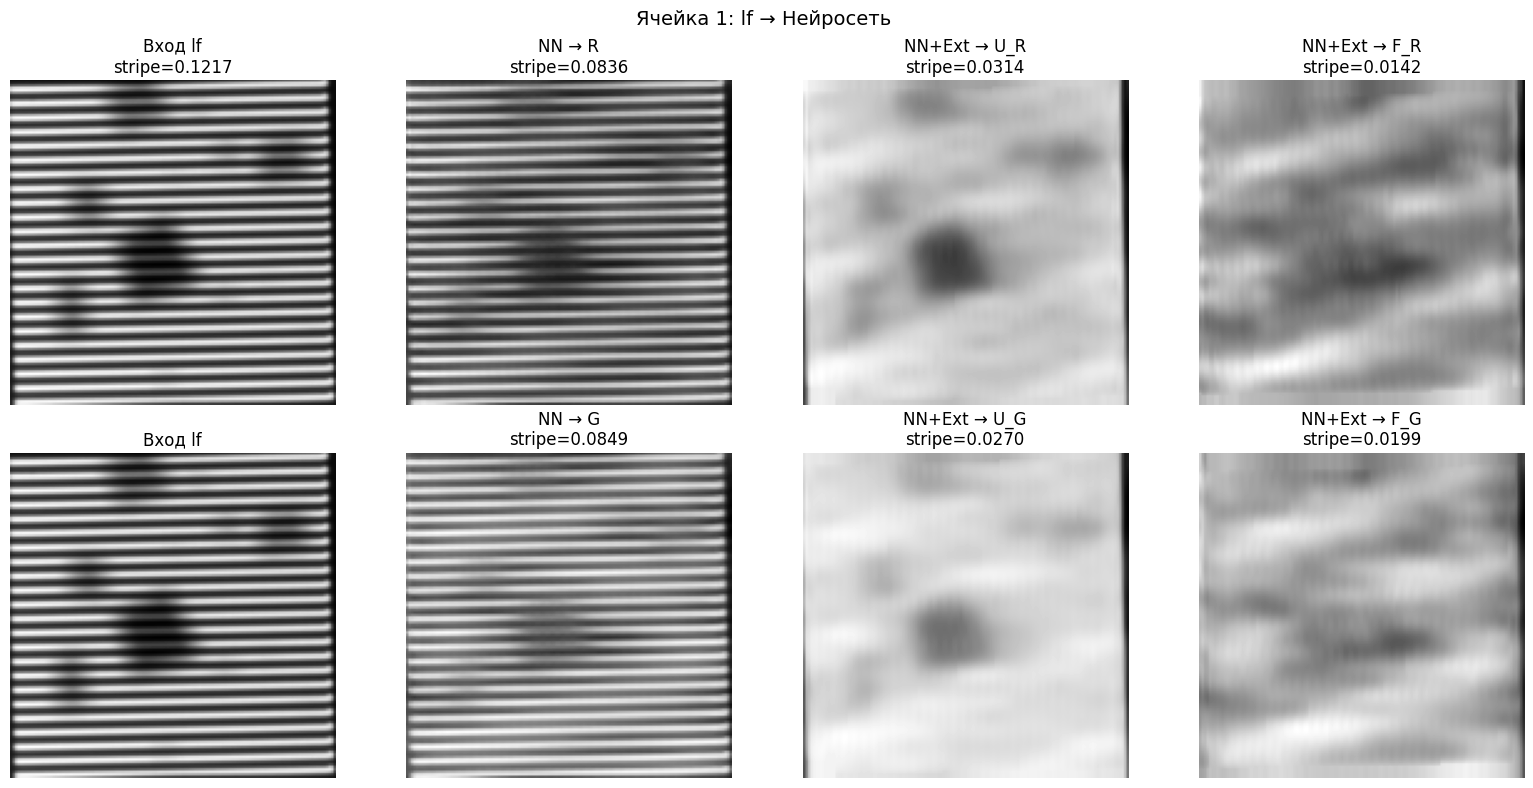

In [32]:
# ЯЧЕЙКА 1: lf.npy → Нейросеть → Код учителя (reconstruct_u_f_from_extrema)
# =============================================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

# ─────────────────────────────────────────────────────────────────────────────
# Функции из кода учителя
# ─────────────────────────────────────────────────────────────────────────────

def interp_1d_with_fill(y_sparse: np.ndarray, mask: np.ndarray) -> np.ndarray:
    h = len(y_sparse)
    x = np.arange(h, dtype=np.float32)
    x_known = x[mask]
    y_known = y_sparse[mask]
    
    if len(x_known) == 0:
        return np.zeros_like(y_sparse, dtype=np.float32)
    if len(x_known) == 1:
        return np.full_like(y_sparse, y_known[0], dtype=np.float32)
    
    f = interp1d(
        x_known, y_known,
        kind="cubic" if len(x_known) >= 4 else "linear",
        bounds_error=False,
        fill_value=(y_known[0], y_known[-1]),
        assume_sorted=True,
    )
    return f(x).astype(np.float32)


def reconstruct_u_f_from_extrema(img_2d: np.ndarray, scale_h: int = 8, distance: int = 4):
    """
    Применяет reconstruct_u_f_from_extrema к 2D изображению (numpy).
    Возвращает U (огибающая максимумов) и F (огибающая минимумов).
    """
    h, w = img_2d.shape
    
    # Upsample по высоте
    img_t = torch.from_numpy(img_2d).float().unsqueeze(0).unsqueeze(0)
    img_up = F.interpolate(img_t, size=(h * scale_h, w), mode='bilinear', align_corners=False)
    img_up_np = img_up.squeeze().numpy()
    
    h_up, w_up = img_up_np.shape
    
    U_sparse = np.zeros((h_up, w_up), dtype=np.float32)
    F_sparse = np.zeros((h_up, w_up), dtype=np.float32)
    U_mask = np.zeros((h_up, w_up), dtype=bool)
    F_mask = np.zeros((h_up, w_up), dtype=bool)
    
    for j in range(w_up):
        col = img_up_np[:, j]
        
        peaks, _ = find_peaks(col, distance=distance)
        valleys, _ = find_peaks(-col, distance=distance)
        
        if len(peaks) == 0:
            peaks = np.array([int(np.argmax(col))], dtype=np.int32)
        if len(valleys) == 0:
            valleys = np.array([int(np.argmin(col))], dtype=np.int32)
        
        U_sparse[peaks, j] = col[peaks]
        U_mask[peaks, j] = True
        F_sparse[valleys, j] = col[valleys]
        F_mask[valleys, j] = True
    
    # Интерполяция
    U_up = np.zeros_like(U_sparse)
    F_up = np.zeros_like(F_sparse)
    
    for j in range(w_up):
        U_up[:, j] = interp_1d_with_fill(U_sparse[:, j], U_mask[:, j])
        F_up[:, j] = interp_1d_with_fill(F_sparse[:, j], F_mask[:, j])
    
    # Downsample обратно
    U_t = torch.from_numpy(U_up).float().unsqueeze(0).unsqueeze(0)
    F_t = torch.from_numpy(F_up).float().unsqueeze(0).unsqueeze(0)
    
    U = F.interpolate(U_t, size=(h, w), mode='bilinear', align_corners=False).squeeze().numpy()
    F_out = F.interpolate(F_t, size=(h, w), mode='bilinear', align_corners=False).squeeze().numpy()
    
    return U, F_out

# ─────────────────────────────────────────────────────────────────────────────
# Загрузка lf.npy
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("ЯЧЕЙКА 1: lf.npy → Нейросеть → Код учителя")
print("=" * 60)

lf = np.load("lf.npy").astype(np.float32)

# Подготовка
if lf.ndim == 2:
    pass
elif lf.ndim == 3 and lf.shape[0] == 1:
    lf = lf[0]
elif lf.ndim == 3 and lf.shape[-1] == 1:
    lf = lf[:, :, 0]

if lf.max() > 1.1:
    lf = lf / 255.0
lf = np.clip(lf, 0.0, 1.0)

print(f"lf.npy shape: {lf.shape}, range: [{lf.min():.3f}, {lf.max():.3f}]")

# ─────────────────────────────────────────────────────────────────────────────
# Инференс нейросети с паддингом
# ─────────────────────────────────────────────────────────────────────────────

# Получаем device из модели
model_device = next(_infer_model.parameters()).device
print(f"Model device: {model_device}")

@torch.no_grad()
def infer_full_padded(model, img):
    """
    Инференс с паддингом до размера кратного 32.
    img: (H, W) float32
    return: (2, H, W)
    """
    dev = next(model.parameters()).device
    h, w = img.shape
    
    # Паддинг до кратного 32
    pad_h = (32 - h % 32) % 32
    pad_w = (32 - w % 32) % 32
    
    # Паддинг: (left, right, top, bottom)
    img_padded = np.pad(img, ((0, pad_h), (0, pad_w)), mode='reflect')
    
    t = torch.tensor(img_padded[None, None], dtype=torch.float32).to(dev)
    with torch.amp.autocast('cuda'):
        out = model(t)
    
    # Убираем паддинг
    out_np = out[0].cpu().numpy()  # (2, H+pad_h, W+pad_w)
    return out_np[:, :h, :w]  # (2, H, W)

print("\n[Шаг 1] Применяем нейросеть...")
nn_output = infer_full_padded(_infer_model, lf)  # (2, H, W)
nn_R = nn_output[0]  # Канал R
nn_G = nn_output[1]  # Канал G

print(f"  NN output R: [{nn_R.min():.3f}, {nn_R.max():.3f}]")
print(f"  NN output G: [{nn_G.min():.3f}, {nn_G.max():.3f}]")

# ─────────────────────────────────────────────────────────────────────────────
# Шаг 2: Применяем код учителя к выходам нейросети
# ─────────────────────────────────────────────────────────────────────────────

SCALE_H = 8
PEAK_DISTANCE = 4

print(f"\n[Шаг 2] Применяем reconstruct_u_f_from_extrema...")
print(f"  scale_h={SCALE_H}, distance={PEAK_DISTANCE}")

U_R, F_R = reconstruct_u_f_from_extrema(nn_R, scale_h=SCALE_H, distance=PEAK_DISTANCE)
U_G, F_G = reconstruct_u_f_from_extrema(nn_G, scale_h=SCALE_H, distance=PEAK_DISTANCE)

print(f"  U_R: [{U_R.min():.3f}, {U_R.max():.3f}]")
print(f"  F_R: [{F_R.min():.3f}, {F_R.max():.3f}]")
print(f"  U_G: [{U_G.min():.3f}, {U_G.max():.3f}]")
print(f"  F_G: [{F_G.min():.3f}, {F_G.max():.3f}]")

# ─────────────────────────────────────────────────────────────────────────────
# Метрика полосатости
# ─────────────────────────────────────────────────────────────────────────────

def stripe_metric(img):
    """Оценка полосатости: std по средним строкам. Меньше = лучше."""
    return np.std(np.mean(img, axis=1))

print("\n" + "=" * 60)
print("МЕТРИКИ ПОЛОСАТОСТИ (меньше = лучше)")
print("=" * 60)
print(f"  Вход lf:     {stripe_metric(lf):.4f}")
print(f"  NN → R:      {stripe_metric(nn_R):.4f}")
print(f"  NN → G:      {stripe_metric(nn_G):.4f}")
print(f"  NN+Ext U_R:  {stripe_metric(U_R):.4f}")
print(f"  NN+Ext F_R:  {stripe_metric(F_R):.4f}")
print(f"  NN+Ext U_G:  {stripe_metric(U_G):.4f}")
print(f"  NN+Ext F_G:  {stripe_metric(F_G):.4f}")


fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Строка 1: Вход и R
axes[0, 0].imshow(lf, cmap='gray')
axes[0, 0].set_title(f'Вход lf\nstripe={stripe_metric(lf):.4f}')
axes[0, 0].axis('off')

axes[0, 1].imshow(nn_R, cmap='gray')
axes[0, 1].set_title(f'NN → R\nstripe={stripe_metric(nn_R):.4f}')
axes[0, 1].axis('off')

axes[0, 2].imshow(U_R, cmap='gray')
axes[0, 2].set_title(f'NN+Ext → U_R\nstripe={stripe_metric(U_R):.4f}')
axes[0, 2].axis('off')

axes[0, 3].imshow(F_R, cmap='gray')
axes[0, 3].set_title(f'NN+Ext → F_R\nstripe={stripe_metric(F_R):.4f}')
axes[0, 3].axis('off')

# Строка 2: G канал
axes[1, 0].imshow(lf, cmap='gray')
axes[1, 0].set_title('Вход lf')
axes[1, 0].axis('off')

axes[1, 1].imshow(nn_G, cmap='gray')
axes[1, 1].set_title(f'NN → G\nstripe={stripe_metric(nn_G):.4f}')
axes[1, 1].axis('off')

axes[1, 2].imshow(U_G, cmap='gray')
axes[1, 2].set_title(f'NN+Ext → U_G\nstripe={stripe_metric(U_G):.4f}')
axes[1, 2].axis('off')

axes[1, 3].imshow(F_G, cmap='gray')
axes[1, 3].set_title(f'NN+Ext → F_G\nstripe={stripe_metric(F_G):.4f}')
axes[1, 3].axis('off')

plt.suptitle('Ячейка 1: lf → Нейросеть ', fontsize=14)
plt.tight_layout()
plt.show()


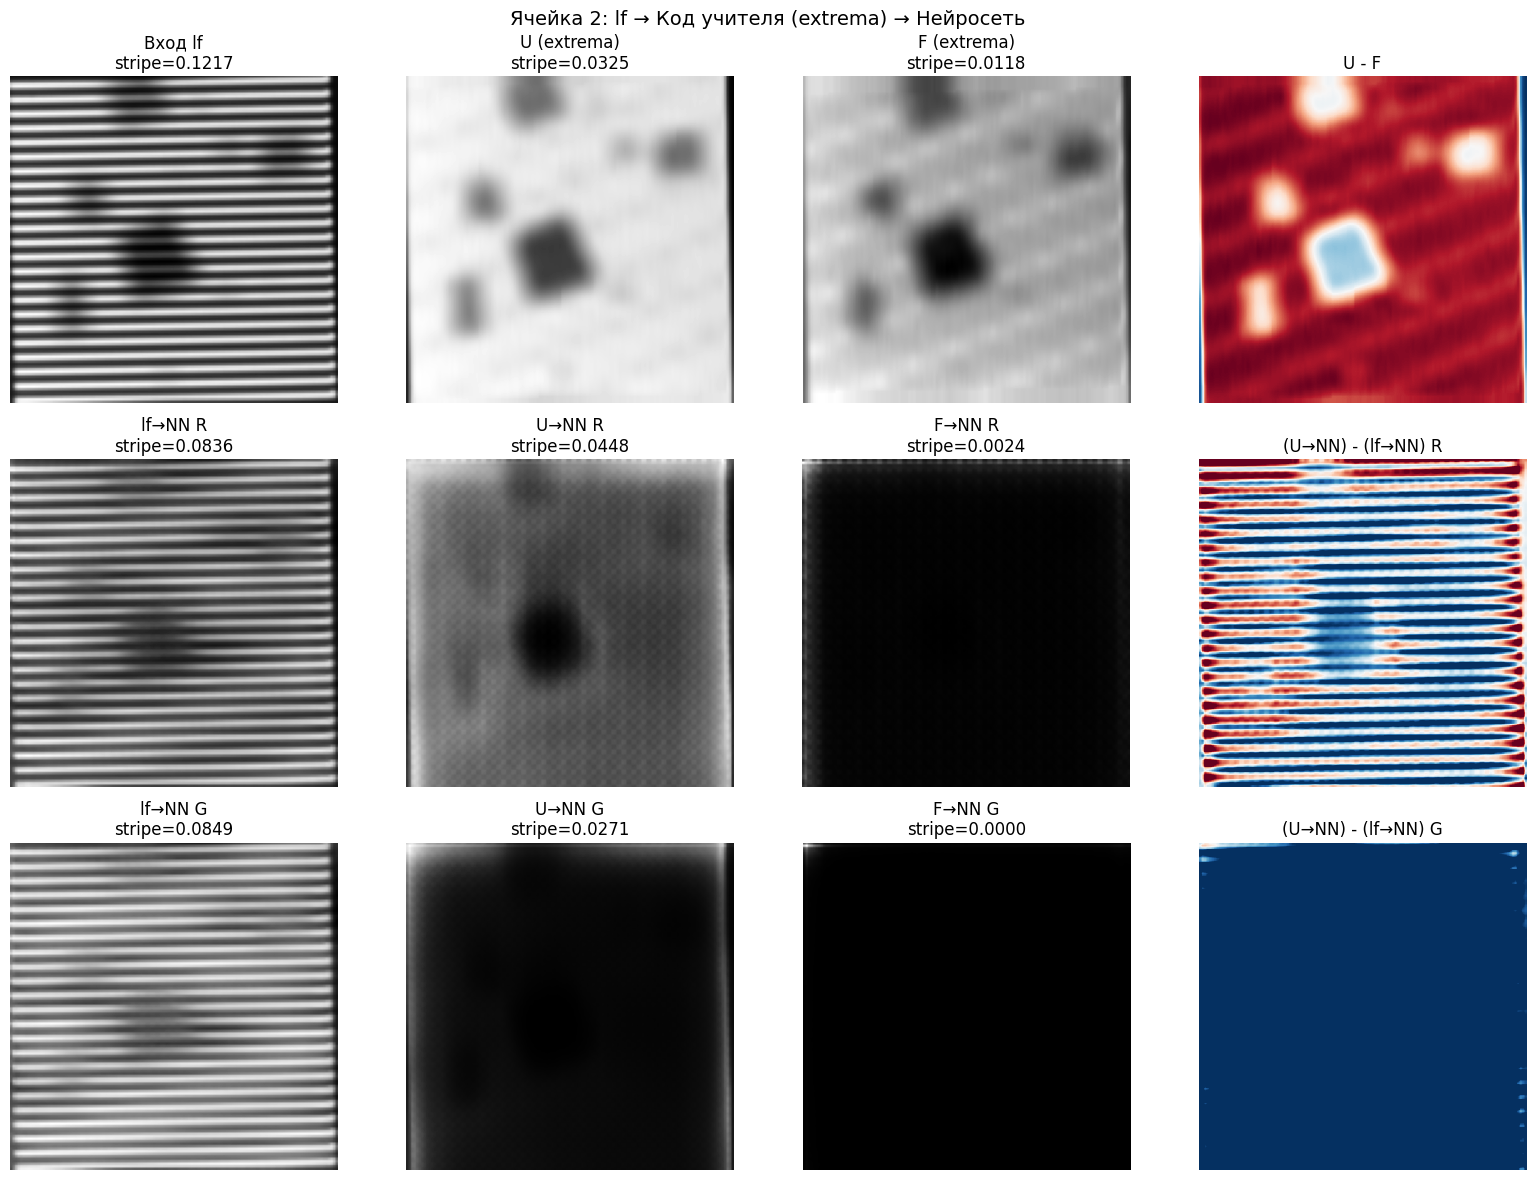

In [34]:
# ЯЧЕЙКА 2: lf.npy → Код учителя (reconstruct_u_f_from_extrema) → Нейросеть
# =============================================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

# ─────────────────────────────────────────────────────────────────────────────
# Функции из кода учителя
# ─────────────────────────────────────────────────────────────────────────────

def interp_1d_with_fill(y_sparse: np.ndarray, mask: np.ndarray) -> np.ndarray:
    h = len(y_sparse)
    x = np.arange(h, dtype=np.float32)
    x_known = x[mask]
    y_known = y_sparse[mask]
    
    if len(x_known) == 0:
        return np.zeros_like(y_sparse, dtype=np.float32)
    if len(x_known) == 1:
        return np.full_like(y_sparse, y_known[0], dtype=np.float32)
    
    f = interp1d(
        x_known, y_known,
        kind="cubic" if len(x_known) >= 4 else "linear",
        bounds_error=False,
        fill_value=(y_known[0], y_known[-1]),
        assume_sorted=True,
    )
    return f(x).astype(np.float32)


def reconstruct_u_f_from_extrema(img_2d: np.ndarray, scale_h: int = 8, distance: int = 4):
    """
    Применяет reconstruct_u_f_from_extrema к 2D изображению (numpy).
    Возвращает U (огибающая максимумов) и F (огибающая минимумов).
    """
    h, w = img_2d.shape
    
    # Upsample по высоте
    img_t = torch.from_numpy(img_2d).float().unsqueeze(0).unsqueeze(0)
    img_up = F.interpolate(img_t, size=(h * scale_h, w), mode='bilinear', align_corners=False)
    img_up_np = img_up.squeeze().numpy()
    
    h_up, w_up = img_up_np.shape
    
    U_sparse = np.zeros((h_up, w_up), dtype=np.float32)
    F_sparse = np.zeros((h_up, w_up), dtype=np.float32)
    U_mask = np.zeros((h_up, w_up), dtype=bool)
    F_mask = np.zeros((h_up, w_up), dtype=bool)
    
    for j in range(w_up):
        col = img_up_np[:, j]
        
        peaks, _ = find_peaks(col, distance=distance)
        valleys, _ = find_peaks(-col, distance=distance)
        
        if len(peaks) == 0:
            peaks = np.array([int(np.argmax(col))], dtype=np.int32)
        if len(valleys) == 0:
            valleys = np.array([int(np.argmin(col))], dtype=np.int32)
        
        U_sparse[peaks, j] = col[peaks]
        U_mask[peaks, j] = True
        F_sparse[valleys, j] = col[valleys]
        F_mask[valleys, j] = True
    
    # Интерполяция
    U_up = np.zeros_like(U_sparse)
    F_up = np.zeros_like(F_sparse)
    
    for j in range(w_up):
        U_up[:, j] = interp_1d_with_fill(U_sparse[:, j], U_mask[:, j])
        F_up[:, j] = interp_1d_with_fill(F_sparse[:, j], F_mask[:, j])
    
    # Downsample обратно
    U_t = torch.from_numpy(U_up).float().unsqueeze(0).unsqueeze(0)
    F_t = torch.from_numpy(F_up).float().unsqueeze(0).unsqueeze(0)
    
    U = F.interpolate(U_t, size=(h, w), mode='bilinear', align_corners=False).squeeze().numpy()
    F_out = F.interpolate(F_t, size=(h, w), mode='bilinear', align_corners=False).squeeze().numpy()
    
    return U, F_out

# ─────────────────────────────────────────────────────────────────────────────
# Загрузка lf.npy
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("ЯЧЕЙКА 2: lf.npy → Код учителя → Нейросеть")
print("=" * 60)

lf = np.load("lf.npy").astype(np.float32)

# Подготовка
if lf.ndim == 2:
    pass
elif lf.ndim == 3 and lf.shape[0] == 1:
    lf = lf[0]
elif lf.ndim == 3 and lf.shape[-1] == 1:
    lf = lf[:, :, 0]

if lf.max() > 1.1:
    lf = lf / 255.0
lf = np.clip(lf, 0.0, 1.0)

print(f"lf.npy shape: {lf.shape}, range: [{lf.min():.3f}, {lf.max():.3f}]")

# ─────────────────────────────────────────────────────────────────────────────
# Шаг 1: Применяем код учителя
# ─────────────────────────────────────────────────────────────────────────────

SCALE_H = 8
PEAK_DISTANCE = 4

print(f"\n[Шаг 1] Применяем reconstruct_u_f_from_extrema...")
print(f"  scale_h={SCALE_H}, distance={PEAK_DISTANCE}")

U_lf, F_lf = reconstruct_u_f_from_extrema(lf, scale_h=SCALE_H, distance=PEAK_DISTANCE)

print(f"  U (максимумы): [{U_lf.min():.3f}, {U_lf.max():.3f}]")
print(f"  F (минимумы):  [{F_lf.min():.3f}, {F_lf.max():.3f}]")

# ─────────────────────────────────────────────────────────────────────────────
# Инференс нейросети с паддингом
# ─────────────────────────────────────────────────────────────────────────────

# Получаем device из модели
model_device = next(_infer_model.parameters()).device
print(f"\nModel device: {model_device}")

@torch.no_grad()
def infer_full_padded(model, img):
    """
    Инференс с паддингом до размера кратного 32.
    img: (H, W) float32
    return: (2, H, W)
    """
    dev = next(model.parameters()).device
    h, w = img.shape
    
    # Паддинг до кратного 32
    pad_h = (32 - h % 32) % 32
    pad_w = (32 - w % 32) % 32
    
    # Паддинг: reflect для лучших краёв
    img_padded = np.pad(img, ((0, pad_h), (0, pad_w)), mode='reflect')
    
    t = torch.tensor(img_padded[None, None], dtype=torch.float32).to(dev)
    with torch.amp.autocast('cuda'):
        out = model(t)
    
    # Убираем паддинг
    out_np = out[0].cpu().numpy()  # (2, H+pad_h, W+pad_w)
    return out_np[:, :h, :w]  # (2, H, W)

# ─────────────────────────────────────────────────────────────────────────────
# Шаг 2: Применяем нейросеть к U, F и оригиналу
# ─────────────────────────────────────────────────────────────────────────────

print("\n[Шаг 2] Применяем нейросеть...")

# Baseline: P → NN
print("  lf → NN...")
nn_direct = infer_full_padded(_infer_model, lf)
nn_direct_R = nn_direct[0]
nn_direct_G = nn_direct[1]

# U → NN
print("  U → NN...")
nn_U = infer_full_padded(_infer_model, U_lf)
nn_U_R = nn_U[0]
nn_U_G = nn_U[1]

# F → NN
print("  F → NN...")
nn_F = infer_full_padded(_infer_model, F_lf)
nn_F_R = nn_F[0]
nn_F_G = nn_F[1]

# ─────────────────────────────────────────────────────────────────────────────
# Метрика полосатости
# ─────────────────────────────────────────────────────────────────────────────

def stripe_metric(img):
    """Оценка полосатости: std по средним строкам. Меньше = лучше."""
    return np.std(np.mean(img, axis=1))

print("\n" + "=" * 60)
print("МЕТРИКИ ПОЛОСАТОСТИ (меньше = лучше)")
print("=" * 60)
print(f"{'Изображение':<20} {'Stripe metric':>12}")
print("-" * 35)
print(f"{'Вход lf':<20} {stripe_metric(lf):>12.4f}")
print(f"{'U (extrema)':<20} {stripe_metric(U_lf):>12.4f}")
print(f"{'F (extrema)':<20} {stripe_metric(F_lf):>12.4f}")
print("-" * 35)
print(f"{'lf→NN R':<20} {stripe_metric(nn_direct_R):>12.4f}")
print(f"{'lf→NN G':<20} {stripe_metric(nn_direct_G):>12.4f}")
print("-" * 35)
print(f"{'U→NN R':<20} {stripe_metric(nn_U_R):>12.4f}")
print(f"{'U→NN G':<20} {stripe_metric(nn_U_G):>12.4f}")
print("-" * 35)
print(f"{'F→NN R':<20} {stripe_metric(nn_F_R):>12.4f}")
print(f"{'F→NN G':<20} {stripe_metric(nn_F_G):>12.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# Визуализация
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Строка 1: Входы
axes[0, 0].imshow(lf, cmap='gray')
axes[0, 0].set_title(f'Вход lf\nstripe={stripe_metric(lf):.4f}')
axes[0, 0].axis('off')

axes[0, 1].imshow(U_lf, cmap='gray')
axes[0, 1].set_title(f'U (extrema)\nstripe={stripe_metric(U_lf):.4f}')
axes[0, 1].axis('off')

axes[0, 2].imshow(F_lf, cmap='gray')
axes[0, 2].set_title(f'F (extrema)\nstripe={stripe_metric(F_lf):.4f}')
axes[0, 2].axis('off')

axes[0, 3].imshow(U_lf - F_lf, cmap='RdBu_r')
axes[0, 3].set_title('U - F')
axes[0, 3].axis('off')

# Строка 2: R канал
axes[1, 0].imshow(nn_direct_R, cmap='gray')
axes[1, 0].set_title(f'lf→NN R\nstripe={stripe_metric(nn_direct_R):.4f}')
axes[1, 0].axis('off')

axes[1, 1].imshow(nn_U_R, cmap='gray')
axes[1, 1].set_title(f'U→NN R\nstripe={stripe_metric(nn_U_R):.4f}')
axes[1, 1].axis('off')

axes[1, 2].imshow(nn_F_R, cmap='gray')
axes[1, 2].set_title(f'F→NN R\nstripe={stripe_metric(nn_F_R):.4f}')
axes[1, 2].axis('off')

# Разница
diff_R = nn_U_R - nn_direct_R
axes[1, 3].imshow(diff_R, cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1, 3].set_title('(U→NN) - (lf→NN) R')
axes[1, 3].axis('off')

# Строка 3: G канал
axes[2, 0].imshow(nn_direct_G, cmap='gray')
axes[2, 0].set_title(f'lf→NN G\nstripe={stripe_metric(nn_direct_G):.4f}')
axes[2, 0].axis('off')

axes[2, 1].imshow(nn_U_G, cmap='gray')
axes[2, 1].set_title(f'U→NN G\nstripe={stripe_metric(nn_U_G):.4f}')
axes[2, 1].axis('off')

axes[2, 2].imshow(nn_F_G, cmap='gray')
axes[2, 2].set_title(f'F→NN G\nstripe={stripe_metric(nn_F_G):.4f}')
axes[2, 2].axis('off')

# Разница
diff_G = nn_U_G - nn_direct_G
axes[2, 3].imshow(diff_G, cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[2, 3].set_title('(U→NN) - (lf→NN) G')
axes[2, 3].axis('off')

plt.suptitle('Ячейка 2: lf → Код учителя (extrema) → Нейросеть', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ЯЧЕЙКА 14: Визуализация результатов на val примерах

 
# Загружаем лучшую модель
_infer_model = UNetASPP(in_ch=1, out_ch=2).to(device)
state = torch.load(BEST_MODEL_PATH, map_location=device)
_infer_model.load_state_dict(state)
_infer_model.eval()
print(f"Модель загружена: {BEST_MODEL_PATH}  |  val_loss best = {best_val_loss:.4f}")
 
 
@torch.no_grad()
def infer_patch(model, P: np.ndarray) -> np.ndarray:
    """P: (H,W) float32  →  rg_pred: (H,W,2) float32"""
    t = torch.tensor(P[None, None], dtype=torch.float32).to(device)
    with torch.amp.autocast('cuda'):
        out = model(t)          # (1, 2, H, W)
    return out[0].cpu().numpy().transpose(1, 2, 0)   # (H,W,2)
 
 
def compute_metrics(pred_rg, gt_rg):
    from skimage.metrics import peak_signal_noise_ratio as psnr_fn
    from skimage.metrics import structural_similarity  as ssim_fn
    m = {}
    for i, ch in enumerate(["R", "G"]):
        m[f"PSNR_{ch}"] = psnr_fn(gt_rg[:,:,i], pred_rg[:,:,i], data_range=1.0)
        m[f"SSIM_{ch}"] = ssim_fn(gt_rg[:,:,i], pred_rg[:,:,i], data_range=1.0)
    m["PSNR_mean"] = (m["PSNR_R"] + m["PSNR_G"]) / 2
    m["SSIM_mean"] = (m["SSIM_R"] + m["SSIM_G"]) / 2
    return m
 
 
# Несколько разных конфигураций масок для демонстрации
DEMO_CONFIGS = [
    ({"type": "h", "width": 16.0},                               "H-stripe 16px"),
    ({"type": "h", "width": 48.0},                               "H-stripe 48px"),
    ({"type": "s", "freq": 1/20, "angle": 0.0,  "phase": 0.0},  "Sin гориз T=20"),
    ({"type": "s", "freq": 1/15, "angle": 45.0, "phase": 1.0},  "Sin диаг  T=15"),
    ({"type": "s", "freq": 1/40, "angle": 90.0, "phase": 2.0},  "Sin верт  T=40"),
]
 
N_IMAGES = 1   # сколько val-изображений показать
 
fig_rows = N_IMAGES * len(DEMO_CONFIGS)
print(f"Всего примеров: {fig_rows}  ({N_IMAGES} изобр × {len(DEMO_CONFIGS)} масок)\n")
 
all_metrics = []
 
for img_i in range(N_IMAGES):
    rg = load_rg(val_paths[img_i])      # (512,512,2)  GT
 
    fig, axes = plt.subplots(
        len(DEMO_CONFIGS), 5,
        figsize=(18, 3.6 * len(DEMO_CONFIGS))
    )
    fig.suptitle(f"Val image #{img_i}  —  {val_paths[img_i].name if hasattr(val_paths[img_i], 'name') else img_i}",
                 fontsize=12, y=1.01)
 
    for row, (config, label) in enumerate(DEMO_CONFIGS):
 
        # Генерация P из GT + маска
        K    = make_mask(512, 512, config)
        P    = make_measurement(rg, K)
 
        # Берём центральный патч 256×256
        y0, x0 = 128, 128
        ps     = PATCH_SIZE
        P_p    = P [y0:y0+ps, x0:x0+ps]
        rg_p   = rg[y0:y0+ps, x0:x0+ps]
        K_p    = K [y0:y0+ps, x0:x0+ps]
 
        pred   = infer_patch(_infer_model, P_p)   # (ps,ps,2)
        m      = compute_metrics(pred, rg_p)
        m["label"] = label
        all_metrics.append(m)
 
        err = (np.abs(pred[:,:,0] - rg_p[:,:,0]) +
               np.abs(pred[:,:,1] - rg_p[:,:,1])) / 2
 
        # Столбцы: Маска K | Вход P | GT (R как серый) | Pred R | Pred G
        panels = [
            (K_p,        "Маска K",  "gray",   0, 1),
            (P_p,        "Вход P",   "gray",   0, 1),
            (rg_p[:,:,0],"GT  R",    "Reds_r", 0, 1),
            (pred[:,:,0],"Pred R",   "Reds_r", 0, 1),
            (pred[:,:,1],"Pred G",   "Greens_r",0,1),
        ]
 
        for col, (img, title, cmap, vmin, vmax) in enumerate(panels):
            ax = axes[row, col] if len(DEMO_CONFIGS) > 1 else axes[col]
            ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
            if col == 0:
                ax.set_ylabel(label, fontsize=8, rotation=0,
                              labelpad=90, va="center")
            if row == 0:
                ax.set_title(title, fontsize=9)
            ax.axis("off")
 
        # Аннотация метрик справа от строки
        axes[row, -1].text(
            1.05, 0.5,
            f"PSNR R={m['PSNR_R']:.1f}\nPSNR G={m['PSNR_G']:.1f}\n"
            f"avg={m['PSNR_mean']:.1f} dB\nSSIM={m['SSIM_mean']:.3f}",
            transform=axes[row, -1].transAxes,
            fontsize=8, va="center",
            bbox=dict(boxstyle="round", fc="lightyellow", ec="gray", alpha=0.8),
        )
 
    plt.tight_layout()
    plt.savefig(f"val_image_{img_i}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close()
 
# ── Итоговая сводка по конфигурациям ────────────────────────────────────────
print("\n" + "="*62)
print(f"{'Конфигурация':<24}  {'PSNR_R':>6}  {'PSNR_G':>6}  {'PSNR avg':>8}  {'SSIM':>6}")
print("="*62)
for label in [c[1] for c in DEMO_CONFIGS]:
    rows = [m for m in all_metrics if m["label"] == label]
    print(f"  {label:<22}  "
          f"{np.mean([r['PSNR_R'] for r in rows]):>6.2f}  "
          f"{np.mean([r['PSNR_G'] for r in rows]):>6.2f}  "
          f"{np.mean([r['PSNR_mean'] for r in rows]):>8.2f}  "
          f"{np.mean([r['SSIM_mean'] for r in rows]):>6.4f}")
print("="*62)
print(f"  {'OVERALL':<22}  "
      f"{np.mean([m['PSNR_R'] for m in all_metrics]):>6.2f}  "
      f"{np.mean([m['PSNR_G'] for m in all_metrics]):>6.2f}  "
      f"{np.mean([m['PSNR_mean'] for m in all_metrics]):>8.2f}  "
      f"{np.mean([m['SSIM_mean'] for m in all_metrics]):>6.4f}")